In [37]:
import numpy as np
from scipy.optimize import minimize
from scipy.integrate import simpson
import matplotlib.pyplot as plt

x = np.load('FIG8_x.npy')
v = np.load('FIG8_v.npy')
potential_test =np.load('FIG8_U.npy')
kinetic_test = np.load('FIG8_T.npy')

samples = np.concatenate((x[0, 0:2, :], x[1, 0:2, :], x[2, 0:2, :]), axis = 1)
v_samples = np.concatenate((v[0, 0:2, :], v[1, 0:2, :], v[2, 0:2, :]), axis = 1)
fc = np.fft.fft(samples, axis = 1)
vfc = np.fft.fft(v_samples, axis = 1)

N = np.shape(x)[0]
K = np.shape(samples)[1]
T = 6.3259



In [ ]:
def calculate_action(x_fourier_coefficients, v_fourier_coefficients, T, K, N):
    omega = 2*np.pi*np.fft.fftfreq(K, d = T/K)
    x = np.zeros((N, 2, K))

    for i in range(N):
        rx_i_fourier_coefficients = x_fourier_coefficients[0, :] * np.exp(1j * omega * i * T / N)
        ry_i_fourier_coefficients = x_fourier_coefficients[1, :] * np.exp(1j * omega * i * T / N)
        x[i, 0, :] = np.fft.ifft(rx_i_fourier_coefficients).real
        x[i, 1, :] = np.fft.ifft(ry_i_fourier_coefficients).real

    # Vectorized pairwise potential calculation
    V = np.zeros(K)

    for t in range(K):
        for i in range(N):
            for j in range(i+1, N):
                x_i, x_j = x[i, :, t], x[j, :, t]
                r_ij = x_j - x_i
                r_ij_norm = np.linalg.norm(r_ij)
                
                #Calculating potentials
                V[t] -= 1/(r_ij_norm + 1e-5)
    #Velocity
    #Move to real space for all N bodies
    KE = np.zeros(K)

    for i in range(N):
        #Shift to find velocity coefficients of each body
        vx_i_fourier_coefficients = v_fourier_coefficients[0, :] * np.exp(1j * omega * i * T / N)
        vy_i_fourier_coefficients = v_fourier_coefficients[1, :] * np.exp(1j * omega * i * T / N)
        
        Vx_i = np.fft.ifft(vx_i_fourier_coefficients).real
        Vy_i = np.fft.ifft(vy_i_fourier_coefficients).real

        KE_i = 0.5*((Vx_i**2)+(Vy_i**2))
        KE += KE_i
    
    #Calc action
    time = np.linspace(0, T, K, endpoint = False)
    L = KE - V
    Sx = simpson(L, x=time)
    return Sx

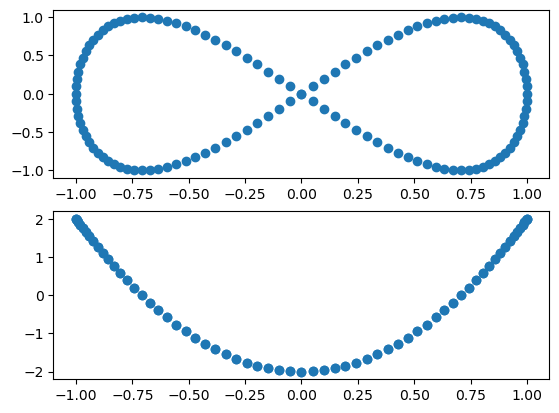

In [29]:
K = 128  # number of time samples
T = 2*np.pi
N = 3
t = np.linspace(0, T, K, endpoint=False)
dt = t[1] - t[0]

def figure8(t):
    x = np.sin(t)
    y = np.sin(2*t)
    return x, y
def v_figure8(t):
    vx = np.cos(t)
    vy = 2*np.cos(2*t)
    return vx, vy

x, y = figure8(t)
vx, vy = v_figure8(t)
fig, ax = plt.subplots(2, 1)
ax[0].scatter(x, y)
ax[1].scatter(vx, vy)
samples = np.vstack((x, y))
v_samples = np.vstack((vx, vy))
fc = np.fft.fft(samples, axis = 1)
vfc = np.fft.fft(v_samples, axis = 1)

In [59]:
def potential(rx_fourier_coefficients, ry_fourier_coefficients, K, N, T):
    omega = 2*np.pi*np.fft.fftfreq(K, d = T/K)
    x = np.zeros((N, 2, K))
    for i in range(N):
        rx_i_fourier_coefficients = rx_fourier_coefficients * np.exp(1j * omega * i * T / N)
        ry_i_fourier_coefficients = ry_fourier_coefficients * np.exp(1j * omega * i * T / N)
        x[i, 0, :] = np.fft.ifft(rx_i_fourier_coefficients).real
        x[i, 1, :] = np.fft.ifft(ry_i_fourier_coefficients).real

    # Vectorized pairwise potential calculation
    V = np.zeros(K)

    for t in range(K):
        for i in range(N):
            for j in range(i+1, N):
                x_i, x_j = x[i, :, t], x[j, :, t]
                r_ij = x_j - x_i
                r_ij_norm = np.linalg.norm(r_ij)
                
                #Calculating potentials
                V[t] -= 1/(r_ij_norm + 1e-5)
    return V

def kinetic_energy(vx_fourier_coefficients, vy_fourier_coefficients, K, N, T):
    #Move to real space for all N bodies
    KE = np.zeros(K)
    omega = 2*np.pi*np.fft.fftfreq(K, d = T/K)
    for i in range(N):
        #Shift to find velocity coefficients of each body
        vx_i_fourier_coefficients = vx_fourier_coefficients * np.exp(1j * omega * i * T / N)
        vy_i_fourier_coefficients = vy_fourier_coefficients * np.exp(1j * omega * i * T / N)
        
        Vx_i = np.fft.ifft(vx_i_fourier_coefficients).real
        Vy_i = np.fft.ifft(vy_i_fourier_coefficients).real

        KE_i = 0.5*((Vx_i**2)+(Vy_i**2))
        KE += KE_i
    return KE

def action(KE, V, K, T):
    time = np.linspace(0, T, K, endpoint = False)
    L = KE - V
    Sx = simpson(L, x=time)
    return Sx

In [60]:
#Find action of curve
V = potential(fc[0, :], fc[1, :], K, N, T)
KE = kinetic_energy(vfc[0, :], vfc[1, :], K, N, T)
S = action(KE, V, K, T)
print(S)

24.304515204862188


In [77]:
def Symmetry_D2dash(coefficients, N, K, indices, direction):
    '''Takes a set of coefficients and applies/removes the symmetry groups restrictions
    When applying them, using direction == "Enforce Restriction", a 1dim array is returned of all real parts
    of coefficients to be perturbed, then all imaginary parts. It also returns the number of restricted coefficients
    When removing them, using direction == "Undo Restriction", it first removes the CoM restrictions, then reconstructs a set
    of K (= no of samples) coefficients
    '''
    if direction == "Enforce Restriction":
        K = np.shape(coefficients)[1]
        
        #CoM Restriction
        indices = np.arange(K)
        CoM_mask = (indices % N != 0)

        #Symmetry Group Restriction
        # Even and Odd masks (excluding CoM restriction)
        Even_mask = (indices % 2 == 0) & CoM_mask
        Odd_mask  = (indices % 2 == 1) & CoM_mask

        #Restrict
        x_real = coefficients[0, :][Even_mask].real
        x_imag = coefficients[0, :][Odd_mask].imag       
        y_real = coefficients[1, :][Odd_mask].real
        y_imag = coefficients[1, :][Even_mask].imag 
        
        #Return restricted coefficients
        restricted_coefficients = np.concatenate((x_real, x_imag, y_real, y_imag))
        return restricted_coefficients, [Even_mask, Odd_mask, CoM_mask], 
    
    elif direction == "Undo Restriction":
        #Unpack index
        [Even_mask, Odd_mask, CoM_mask] = indices
        K_even = (Even_mask & CoM_mask).sum()
        K_odd = (Odd_mask & CoM_mask).sum()

        #Unpack coefficients
        x_restricted_real = coefficients[:K_even]
        x_restricted_imag = coefficients[K_even:(K_even+K_odd)]
        y_restricted_real = coefficients[(K_even+K_odd):(K_even+2*K_odd)]
        y_restricted_imag = coefficients[(K_even+2*K_odd):]

        fourier_coefficients = np.zeros((2, K), dtype = complex)
        for i in range(1, K//2):
            if Even_mask[i] == True:
                fourier_coefficients[0, i] = x_restricted_real[0]
                fourier_coefficients[0, K - i] = -x_restricted_real[0]
                x_restricted_real = x_restricted_real[1:]

                fourier_coefficients[1, i] = 1j*y_restricted_imag[0]
                fourier_coefficients[1, K - i] = -1j*y_restricted_imag[0]
                y_restricted_imag = y_restricted_imag[1:]

            elif Odd_mask[i] == True:
                fourier_coefficients[0, i] = 1j*x_restricted_imag[0]
                fourier_coefficients[0, K - i] = -1j*x_restricted_imag[0]
                x_restricted_imag = x_restricted_imag[1:]

                fourier_coefficients[1, i] = y_restricted_real[0]
                fourier_coefficients[1, K - i] = -y_restricted_real[0]
                y_restricted_real = y_restricted_real[1:]
        
        kur = np.shape(fourier_coefficients)
        return fourier_coefficients, kur
    
    else:
        return "Invalid entry for direction parameter."


In [62]:
def check_imaginary_parts(arr, tol=1e-14):
    imag_parts = np.abs(np.imag(arr))
    max_imag = imag_parts.max()
    has_large_imag = max_imag > tol
    return has_large_imag

In [63]:
coeffs = np.fft.rfft(samples, axis = 1)
K = np.shape(samples)[1]
omega = 2*np.pi*np.fft.fftfreq(K, d = T/K)
restricted_coeffs, index = Symmetry_D2dash(coeffs, N, None, None, "Enforce Restriction")
x_fourier_coefficients, KUr = Symmetry_D2dash(restricted_coeffs, N, K, index, "Undo Restriction")
x = np.fft.ifft(x_fourier_coefficients, axis = 1)
v_fourier_coefficients = 1j*omega[None, :]*x_fourier_coefficients
v = np.fft.ifft(v_fourier_coefficients, axis = 1)
print(check_imaginary_parts(x))
print(check_imaginary_parts(v))

False
False


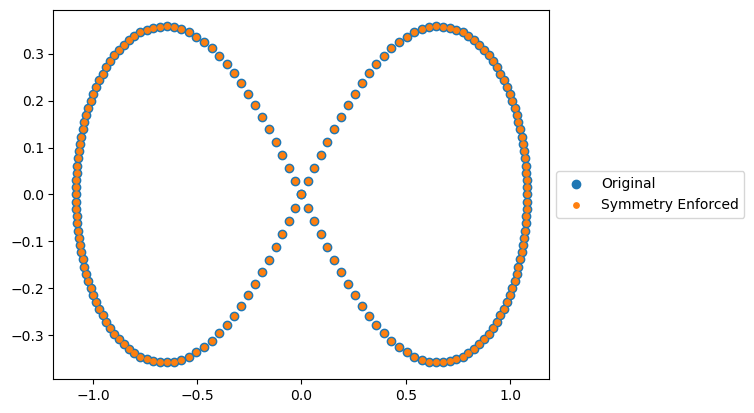

In [78]:
plt.scatter(samples[0, :], samples[1,:], label='Original')
plt.scatter(x[0, :].real, x[1, :].real, label = 'Symmetry Enforced', s = 15)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5)) 


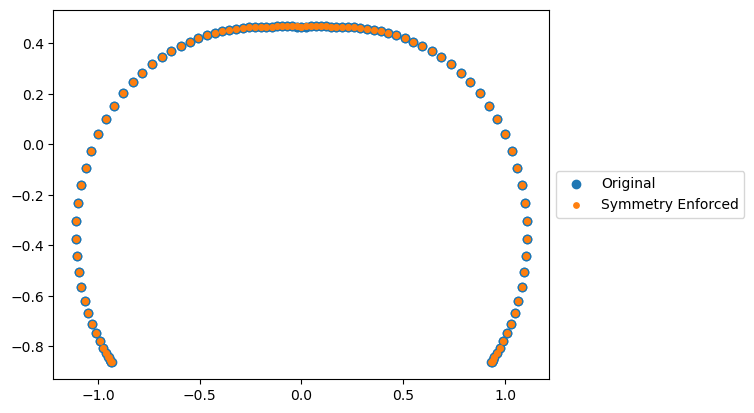

In [79]:
plt.scatter(v_samples[0, :], v_samples[1,:], label='Original')
plt.scatter(v[0, :].real, v[1, :].real,  label = 'Symmetry Enforced', s = 15)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5)) 


In [80]:
def Sx(perturb, N, K, indices, T):
    #Find frequencies and angular velocity
    omega = 2*np.pi*np.fft.fftfreq(K, d = T/K)

    #Apply time-shift
    time_shift = perturb[0]
    coeffs = perturb[1:] 

    #Unpack coefficients
    x_fourier_coefficients, KUr = Symmetry_D2dash(coeffs, N, K, indices, "Undo Restriction")
    x_fourier_coefficients_shifted = x_fourier_coefficients * np.exp(1j * omega * time_shift)

    #Generate velocity coefficients
    v_fourier_coefficients_shifted = 1j*omega[None, :]*x_fourier_coefficients_shifted

    #Calculate action
    KE = kinetic_energy(v_fourier_coefficients_shifted[0, :], v_fourier_coefficients_shifted[1, :], K, N, T)
    V = potential(x_fourier_coefficients_shifted[0, :], x_fourier_coefficients_shifted[1, :], K, N, T)
    Sx = action(KE, V, K, T)
    return Sx

In [81]:
def minimizer(samples, N, T):
    #Find frequencies, angular velocity, and coefficients
    K = np.shape(samples)[1]
    omega = 2*np.pi*np.fft.fftfreq(K, d = T/K)
    coefficients = np.fft.rfft(samples, axis = 1)
    
    initial_coefficients, indices = Symmetry_D2dash(coefficients, N, K, None, "Enforce Restriction")
    
    perturb = np.zeros(np.shape(initial_coefficients)[0]+1)
    perturb[0] = 0                      #Initial Time Shift
    perturb[1:] = initial_coefficients  #Initial FCs

    #Minimize
    min_perturbed_values = minimize(Sx, perturb, method = 'L-BFGS-B', args=(N, K, indices, T))
    #min_fourier_coefficients = minimize(Sx, min_fourier_coefficients_int.x, method='Nelder-Mead', options={'xatol': 1e-12, 'fatol': 1e-12, 'maxiter': 2000}, args=(N, K, indices, T))
    
    #Unpack coefficients (Take all FCs and leave time shift)
    x_fourier_coefficients, KUr = Symmetry_D2dash(min_perturbed_values.x[1:], N, K, indices, "Undo Restriction")
 
    #Generate velocity coefficients
    v_fourier_coefficients = 1j*omega[None, :]*x_fourier_coefficients

    #Move to real space
    x = np.fft.ifft(x_fourier_coefficients, axis = 1).real
    v = np.fft.ifft(v_fourier_coefficients, axis = 1).real

    imaginary_parts_x, imaginary_parts_v = check_imaginary_parts(x), check_imaginary_parts(v)

    return [x, v], [x_fourier_coefficients, v_fourier_coefficients], [min_perturbed_values.success, imaginary_parts_x, imaginary_parts_v]

In [82]:
phasedata, coefficientdata, Result = minimizer(samples, N, T)
# coefficientdata = [x_fourier_coefficients, v_fourier_coefficients]
print(Result)

[False, np.False_, np.False_]


In [83]:
#Find action of curve
V = potential(coefficientdata[0][0, :], coefficientdata[0][1, :], K, N, T)
KE = kinetic_energy(coefficientdata[1][0, :], coefficientdata[1][1, :], K, N, T)
S = action(KE, V, K, T)
print(S)

23.38045163292924


In [84]:
x_chor = np.zeros((3, 3))
v_chor = np.zeros((3, 3))
omega = 2*np.pi*np.fft.fftfreq(K, d = T/K)

for i in range(N):
    x_i_fourier_coefficients = coefficientdata[0][0, :] * np.exp(-1j * omega * i * T / N)
    y_i_fourier_coefficients = coefficientdata[0][1, :] * np.exp(-1j * omega * i * T / N)
    x_chor[i, 0] = np.fft.ifft(x_i_fourier_coefficients)[0].real
    x_chor[i, 1] = np.fft.ifft(y_i_fourier_coefficients)[0].real
    
    vx_i_fourier_coefficients = coefficientdata[1][0, :] * np.exp(-1j * omega * i * T / N)
    vy_i_fourier_coefficients = coefficientdata[1][1, :] * np.exp(-1j * omega * i * T / N)
    v_chor[i, 0] = np.fft.ifft(vx_i_fourier_coefficients)[0].real
    v_chor[i, 1] = np.fft.ifft(vy_i_fourier_coefficients)[0].real

print(x_chor)
print(v_chor)
np.save('x_chor_output.npy', x_chor)
np.save('v_chor_output.npy', v_chor)

[[ 0.          0.          0.        ]
 [ 0.97105346 -0.24302074  0.        ]
 [-0.97105346  0.24302074  0.        ]]
[[-1.37318059 -1.32692577  0.        ]
 [ 0.6865903   0.66346288  0.        ]
 [ 0.6865903   0.66346288  0.        ]]


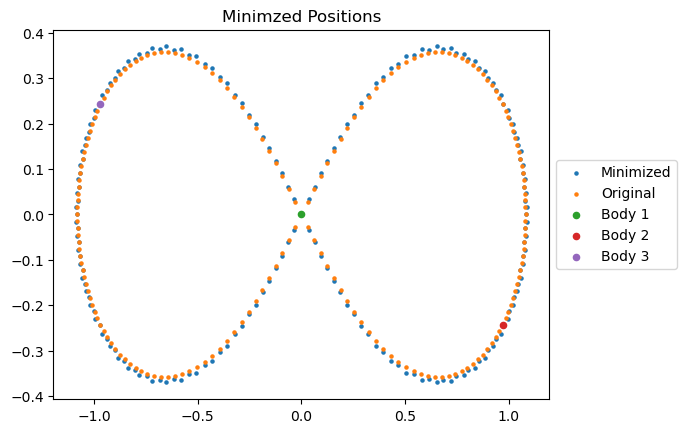

In [85]:
plt.scatter(phasedata[0][0, :], phasedata[0][1, :], s=5, label='Minimized')
plt.scatter(samples[0, :], samples[1, :], s=5, label='Original')
plt.scatter(x_chor[0, 0], x_chor[0, 1], label = 'Body 1', s = 20)
plt.scatter(x_chor[1, 0], x_chor[1, 1], label = 'Body 2', s = 20)
plt.scatter(x_chor[2, 0], x_chor[2, 1], label = 'Body 3', s = 20)
plt.title("Minimzed Positions")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

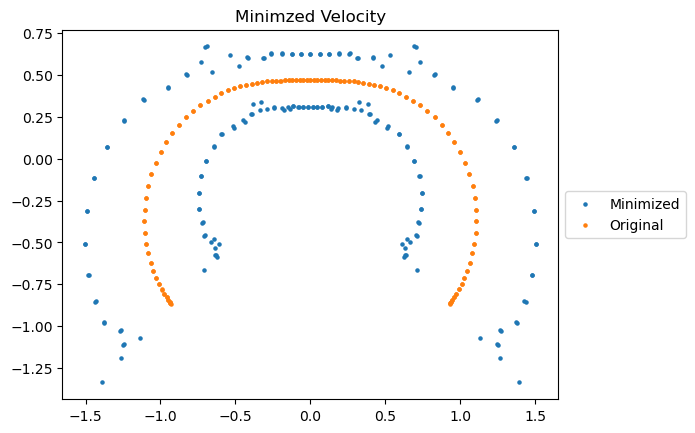

In [74]:
plt.scatter(phasedata[1][0, :], phasedata[1][1, :], s=5,  label='Minimized')
plt.scatter(v_samples[0, :], v_samples[1, :], s=5, label='Original')
plt.title("Minimzed Velocity")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5)) 

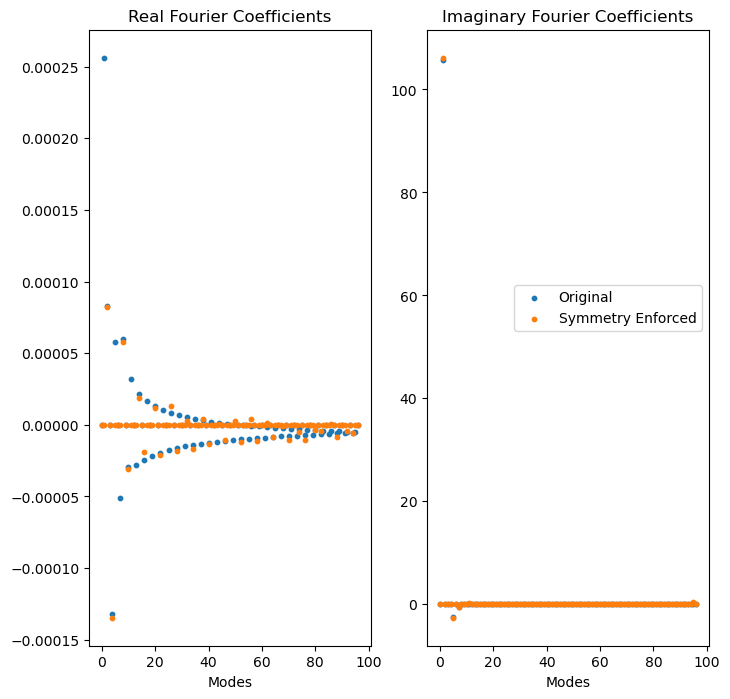

In [86]:
#Compare x Fourier coeffs
modes = np.arange(K//2+1)
fig, ax = plt.subplots(1, 2, figsize = (8, 8))
ax[0].scatter(modes, fc[0, :K//2+1].real, s = 10, label='Original')
ax[1].scatter(modes, fc[0, :K//2+1].imag, s = 10, label='Original')
ax[0].scatter(modes, coefficientdata[0][0, :K//2+1].real, s = 10,  label = 'Symmetry Enforced')
ax[1].scatter(modes, coefficientdata[0][0, :K//2+1].imag, s = 10,  label = 'Symmetry Enforced')

ax[0].set_title("Real Fourier Coefficients")
ax[0].set_xlabel("Modes")
ax[1].set_title("Imaginary Fourier Coefficients")
ax[1].set_xlabel("Modes")
ax[1].legend(loc='lower right', bbox_to_anchor=(1, 0.5)) 

1.0000361637984942


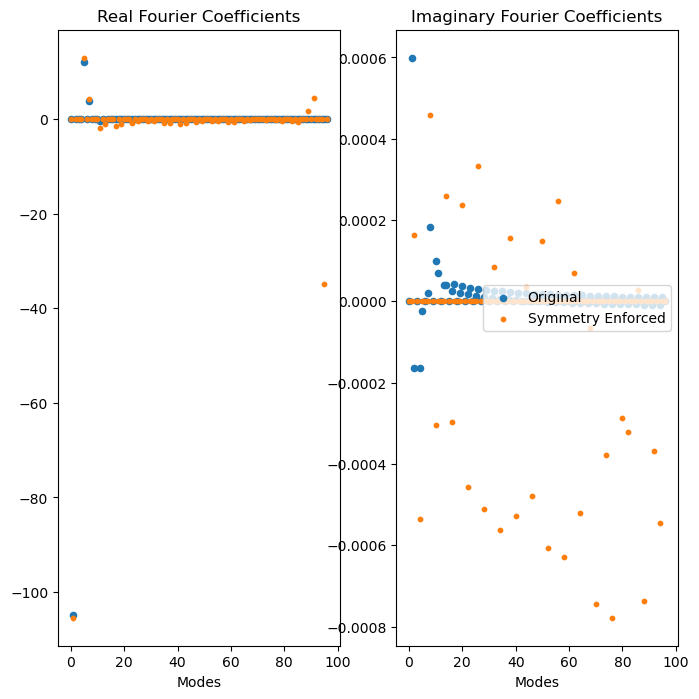

In [87]:
#Compare v Fourier coeffs
modes = np.arange(K//2+1)
fig, ax = plt.subplots(1, 2, figsize = (8, 8))
ax[0].scatter(modes, vfc[0, :K//2+1].real, s = 20, label='Original')
ax[1].scatter(modes, vfc[0, :K//2+1].imag, s = 20, label='Original')
ax[0].scatter(modes, coefficientdata[1][0, :K//2+1].real, s = 10,  label = 'Symmetry Enforced')
ax[1].scatter(modes, coefficientdata[1][0, :K//2+1].imag, s = 10,  label = 'Symmetry Enforced')

ax[0].set_title("Real Fourier Coefficients")
ax[0].set_xlabel("Modes")
ax[1].set_title("Imaginary Fourier Coefficients")
ax[1].set_xlabel("Modes")
ax[1].legend(loc='lower right', bbox_to_anchor=(1, 0.5)) 
print(vfc[0, 5].real/v_fourier_coefficients[0, 5].real)